In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
poverty_path = 'D:/Data Analysis/data/poverty.dta'

In [3]:
s01_path = 'D:/Data Analysis/data/S01.dta'

In [4]:
s02_path = 'D:/Data Analysis/data/S02.dta'

In [5]:
s07_path = "D:/Data Analysis/data/S07.dta"

In [6]:
weight_path = 'D:/Data Analysis/Data/weight.dta'

In [7]:
df_poverty = pd.read_stata(poverty_path)

In [8]:
df_s01 = pd.read_stata(s01_path)

In [9]:
df_s02 = pd.read_stata(s02_path)

In [10]:
df_s07 = pd.read_stata(s07_path)

In [11]:
df_weight = pd.read_stata(weight_path)

In [12]:
print(df_poverty.shape)
print(df_s01.shape)
print(df_s02.shape)
print(df_weight.shape)

(9600, 17)
(46870, 19)
(9600, 62)
(9600, 9)


In [13]:
def create_hh_id(df):
    df["hh_id"] = (
        df["psu_number"].astype(int).astype(str)
        + "_"
        + df["hh_number"].astype(int).astype(str)
    )
    return df

df_poverty = create_hh_id(df_poverty)
df_s01 = create_hh_id(df_s01)
df_s02 = create_hh_id(df_s02)
df_s07 = create_hh_id(df_s07)

In [14]:
df_s01.head()

,psu_number,hh_number,idcode,q01_01,q01_02,q01_03,q01_04,q01_05,q01_06,q01_07,q01_08,q01_09,q01_10,q01_11,q01_12,q01_13,q01_14,q01_15,member_cat,hh_id
0,4001.0,1.0,1.0,not disclosed,Female,29,HEAD,Married,3.0,Mountain/Hill Janajati,12,YES,NO,NaN,Class 4,NO,NaN,Illiterate,Household Member,4001_1
1,4001.0,1.0,2.0,not disclosed,Male,7,SON/DAUGHTER,NaN,NaN,Mountain/Hill Janajati,12,YES,NO,NaN,Class 8,YES,1.0,NaN,Household Member,4001_1
2,4001.0,1.0,3.0,not disclosed,Male,31,HUSBAND/WIFE,Married,1.0,Mountain/Hill Janajati,8,NO,NaN,NaN,NaN,NaN,NaN,NaN,Absentees abroad,4001_1
3,4001.0,2.0,2.0,not disclosed,Female,32,HUSBAND/WIFE,Married,1.0,Mountain/Hill Janajati,12,YES,NO,NaN,Class 7,NO,NaN,Illiterate,Household Member,4001_2
4,4001.0,2.0,1.0,not disclosed,Male,32,HEAD,Married,2.0,Mountain/Hill Janajati,12,YES,NO,NaN,Class 2,NO,NaN,Illiterate,Household Member,4001_2


In [15]:
s01_cols = [
    "psu_number",
    "hh_number",
    "hh_id",
    "q01_09",   
    "q01_02",   
    "q01_03",   
    "q01_04",  
    "idcode" 
]

df_s01 = df_s01[s01_cols].copy()


In [16]:
df_s01.isna().sum()

psu_number    0
hh_number     0
hh_id         0
q01_09        0
q01_02        0
q01_03        0
q01_04        0
idcode        0
dtype: int64

In [17]:
df_s01.head()

,psu_number,hh_number,hh_id,q01_09,q01_02,q01_03,q01_04,idcode
0,4001.0,1.0,4001_1,YES,Female,29,HEAD,1.0
1,4001.0,1.0,4001_1,YES,Male,7,SON/DAUGHTER,2.0
2,4001.0,1.0,4001_1,NO,Male,31,HUSBAND/WIFE,3.0
3,4001.0,2.0,4001_2,YES,Female,32,HUSBAND/WIFE,2.0
4,4001.0,2.0,4001_2,YES,Male,32,HEAD,1.0


In [18]:
df_s01["q01_04"].value_counts()

q01_04
SON/DAUGHTER                   17956
HEAD                            9600
HUSBAND/WIFE                    7998
GRANDCHILD                      4126
DAUGHTER-IN-LAW/SON-IN-LAW      2798
FATHER/MOTHER                   1395
BROTHER/SISTER                   840
OTHER FAMILY RELATIVE            638
FATHER/MOTHER-IN-LAW             563
BROTHER/SISTER-IN-LAW            401
NEPHEW/NIECE                     374
OTHER PERSON NOT RELATED         151
SERVANT/SERVANT’S RELATIVES       30
Name: count, dtype: int64

In [19]:
df_s01["q01_02"].value_counts()

q01_02
Male      23946
Female    22924
Name: count, dtype: int64

In [20]:
df_s01.q01_09.describe()

count     46870
unique        2
top         YES
freq      38101
Name: q01_09, dtype: object

In [21]:
df_s01 = df_s01[df_s01["q01_09"] == "YES"].copy()

In [22]:
df_s01.q01_09.describe()

count     38101
unique        1
top         YES
freq      38101
Name: q01_09, dtype: object

In [23]:
df_s01["q01_09"].value_counts()

q01_09
YES    38101
NO         0
Name: count, dtype: int64

In [ ]:
# df_s01["hh_id"] = df_s01['psu_number'].astype(int).astype(str) + "_" + df_s01['hh_number'].astype(int).astype(str)

In [24]:
df_s01[["psu_number", "hh_number", "hh_id"]].head(5)


,psu_number,hh_number,hh_id
0,4001.0,1.0,4001_1
1,4001.0,1.0,4001_1
3,4001.0,2.0,4001_2
4,4001.0,2.0,4001_2
6,4001.0,3.0,4001_3


In [25]:
df_s01["is_head"] = (df_s01["q01_04"] == "HEAD").astype(int)

In [29]:
head_check = df_s01.groupby("hh_id")["is_head"].sum()

In [30]:
df_s01["is_head"].value_counts()

is_head
0    28501
1     9600
Name: count, dtype: int64

In [30]:
head_check = df_s01.groupby("hh_id")["is_head"].sum()

In [31]:
head_check.head()

hh_id
4001_1     1
4001_10    1
4001_11    1
4001_12    1
4001_2     1
Name: is_head, dtype: int64

In [31]:
head_check.value_counts()

is_head
1    9600
Name: count, dtype: int64

In [40]:
hh_size = df_s01.groupby("hh_id").size().reset_index(name="hh_size")

In [38]:
hh_size.head()

,hh_id,hh_size
0,4001_1,2
1,4001_10,5
2,4001_11,6
3,4001_12,8
4,4001_2,2


In [41]:
df_s01.head()

,psu_number,hh_number,q01_09,q01_02,q01_03,q01_04,idcode,hh_id,is_head
0,4001.0,1.0,YES,Female,29,HEAD,1.0,4001_1,1
1,4001.0,1.0,YES,Male,7,SON/DAUGHTER,2.0,4001_1,0
3,4001.0,2.0,YES,Female,32,HUSBAND/WIFE,2.0,4001_2,0
4,4001.0,2.0,YES,Male,32,HEAD,1.0,4001_2,1
6,4001.0,3.0,YES,Female,5,SON/DAUGHTER,2.0,4001_3,0


In [ ]:
df_s02['q02_32'].value_counts(dropna=False)

keep_cols = [
    'hh_number',
    'psu_number',
    'q02_32',
    'q02_33',
    'q02_28',
    'q02_29',
    'q02_30',
    'q02_11'
]

df_s02 = df_s02[keep_cols]


In [ ]:
# df1["dependent"] = ((df1["q01_03"] < 15) | (df1["q01_03"] > 64)).astype(int)
# dependents = df1.groupby("hh_id")["dependent"].sum().reset_index(name="num_dependents") # count dependetss in each household and sum

In [ ]:
# hh_summary = hh_size.merge(dependents, on="hh_id")

In [55]:
heads = df_s01[df_s01["is_head"] == 1].copy()

df_s01_hh = heads[["hh_id", "q01_02", "q01_03",]].rename(columns={
    "q01_02": "head_gender",
    "q01_03": "head_age"
})

#Female=1, Male=0
df_s01_hh["head_gender"] = df_s01_hh["head_gender"].map({"Female": 1, "Male": 0})


In [40]:
heads.head()

,psu_number,hh_number,q01_09,q01_02,q01_03,q01_04,idcode,hh_id,is_head
0,4001.0,1.0,YES,Female,29,HEAD,1.0,4001_1,1
4,4001.0,2.0,YES,Male,32,HEAD,1.0,4001_2,1
7,4001.0,3.0,YES,Female,28,HEAD,1.0,4001_3,1
10,4001.0,4.0,YES,Female,37,HEAD,1.0,4001_4,1
13,4001.0,5.0,YES,Female,19,HEAD,1.0,4001_5,1


In [56]:
df_s01_hh.head()

,hh_id,head_gender,head_age
0,4001_1,1,29
4,4001_2,0,32
7,4001_3,1,28
10,4001_4,1,37
13,4001_5,1,19


In [ ]:
# # Merge head info with household summary
# df1_hh = hh_summary.merge(head_vars, on="hh_id")

In [ ]:
# print(df1_hh.head())

     hh_id  hh_size  num_dependents head_gender  head_age
0   4001_1        2               1           1        29
1  4001_10        5               2           0        44
2  4001_11        6               3           0        50
3  4001_12        8               3           1        29
4   4001_2        2               0           0        32


In [ ]:
# dependents = df1.groupby("hh_id")["dependent"].sum().reset_index(name="num_dependents")

In [57]:
df_s07.head(20)

,psu_number,hh_number,idcode,q07_01,q07_02,q07_03,q07_04,q07_05,q07_06,q07_07,...,q07_17_b,q07_17_c,q07_17_d,q07_17_e,q07_17_f,q07_17_g,q07_18,q07_19,q07_20,q07_21
0,4001,1,1,1.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,Class 7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4001,1,2,1.0,YES,YES,CURRENT SCHOOLING,NaN,NaN,NaN,...,1800.0,4500.0,6250.0,0.0,8400.0,2000.0,NO,NaN,NaN,NaN
2,4001,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4001,2,1,1.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,Class 5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4001,2,2,2.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,SEE/SLC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4001,3,1,1.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY (PUBLIC) COLLEGE,Intermediate/Class 12,Education,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4001,3,2,1.0,YES,NO,CURRENT SCHOOLING,NaN,NaN,NaN,...,2500.0,4000.0,3500.0,0.0,0.0,0.0,NO,NaN,NaN,NaN
7,4001,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4001,4,1,2.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,Class 8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,4001,4,2,2.0,YES,YES,SCHOOL ATTENDED IN PAST,COMMUNITY / GOVERNMENT SCHOOL,Class 9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
df_s07.q07_04.head(20
                )

0     SCHOOL ATTENDED IN PAST
1           CURRENT SCHOOLING
2                         NaN
3     SCHOOL ATTENDED IN PAST
4     SCHOOL ATTENDED IN PAST
5     SCHOOL ATTENDED IN PAST
6           CURRENT SCHOOLING
7                         NaN
8     SCHOOL ATTENDED IN PAST
9     SCHOOL ATTENDED IN PAST
10          CURRENT SCHOOLING
11    SCHOOL ATTENDED IN PAST
12                        NaN
13                        NaN
14    SCHOOL ATTENDED IN PAST
15          CURRENT SCHOOLING
16          CURRENT SCHOOLING
17      NEVER ATTENDED SCHOOL
18                        NaN
19    SCHOOL ATTENDED IN PAST
Name: q07_04, dtype: category
Categories (3, str): ['NEVER ATTENDED SCHOOL' < 'SCHOOL ATTENDED IN PAST' < 'CURRENT SCHOOLING']

In [59]:
s07_cols = [
    "psu_number",
    "hh_number",
    "idcode",
    "q07_01",
    "q07_03",
    "q07_06"
]

df_s07 = df_s07[s07_cols].copy()

In [46]:
# Extract only head rows from S01
s01_heads = df1[df1["is_head"] == 1][["psu_number", "hh_number", "hh_id"]]

In [47]:
s01_heads.head()

,psu_number,hh_number,hh_id
0,4001.0,1.0,4001_1
4,4001.0,2.0,4001_2
7,4001.0,3.0,4001_3
10,4001.0,4.0,4001_4
13,4001.0,5.0,4001_5


In [48]:
# Merge S07 with head info
head_edu = df7.merge(s01_heads, on=["psu_number", "hh_number"], how="inner")

In [49]:
head_edu.head()

,psu_number,hh_number,idcode,q07_06,q07_01,q07_03,hh_id
0,4001,1,1,Class 7,1.0,YES,4001_1
1,4001,1,2,NaN,1.0,YES,4001_1
2,4001,1,3,NaN,NaN,NaN,4001_1
3,4001,2,1,Class 5,1.0,YES,4001_2
4,4001,2,2,SEE/SLC,2.0,YES,4001_2


In [50]:

df1_hh["hh_id"].nunique(), head_edu["hh_id"].nunique()

(9600, 9600)

In [51]:
df7.q07_06

0        Class 7
1            NaN
2            NaN
3        Class 5
4        SEE/SLC
          ...   
46865    Class 9
46866        NaN
46867        NaN
46868        NaN
46869        NaN
Name: q07_06, Length: 46870, dtype: category
Categories (18, str): ['Pre-school/kindergarden' < 'Class 1' < 'Class 2' < 'Class 3' ... 'Master level or higher' < 'Professional degree' < 'Literate (levelless)' < 'Illiterate']

In [52]:
df2.head()

,hh_number,psu_number,q02_32,q02_33,q02_28,q02_29,q02_30,q02_11
0,1,4001,LP GAS,GAS STOVE,ELECTRICITY,YES,600,YES
1,2,4001,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,780,NO
2,3,4001,LP GAS,GAS STOVE,ELECTRICITY,YES,3600,YES
3,4,4001,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,600,YES
4,5,4001,FIREWOOD,MUD/CLAY STOVE,OTHER,NO,0,YES


In [53]:
df2["hh_id"] = (
    df2["psu_number"].astype(int).astype(str) + "_" +
    df2["hh_number"].astype(int).astype(str)
)

In [54]:
df2['q02_32'].value_counts(dropna=False)

q02_32
FIREWOOD       5419
LP GAS         3861
DUNG            139
BIO-GAS         115
ELECTRICITY      34
OTHER            32
Name: count, dtype: int64

In [55]:
clean_fuels = ["LP GAS", "ELECTRICITY", "BIO-GAS"]

df2["clean_fuel"] = df2["q02_32"].apply(lambda x: 1 if x in clean_fuels else 0)

In [56]:
df2.head()

,hh_number,psu_number,q02_32,q02_33,q02_28,q02_29,q02_30,q02_11,hh_id,clean_fuel
0,1,4001,LP GAS,GAS STOVE,ELECTRICITY,YES,600,YES,4001_1,1
1,2,4001,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,780,NO,4001_2,0
2,3,4001,LP GAS,GAS STOVE,ELECTRICITY,YES,3600,YES,4001_3,1
3,4,4001,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,600,YES,4001_4,0
4,5,4001,FIREWOOD,MUD/CLAY STOVE,OTHER,NO,0,YES,4001_5,0


In [57]:
df2["housing"] = df2["q02_11"].map({"YES": 1, "NO": 0})

In [58]:
df2.head()

,hh_number,psu_number,q02_32,q02_33,q02_28,q02_29,q02_30,q02_11,hh_id,clean_fuel,housing
0,1,4001,LP GAS,GAS STOVE,ELECTRICITY,YES,600,YES,4001_1,1,1
1,2,4001,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,780,NO,4001_2,0,0
2,3,4001,LP GAS,GAS STOVE,ELECTRICITY,YES,3600,YES,4001_3,1,1
3,4,4001,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,600,YES,4001_4,0,1
4,5,4001,FIREWOOD,MUD/CLAY STOVE,OTHER,NO,0,YES,4001_5,0,1


In [59]:
hh_data = df1_hh.merge(
    df2[["hh_id", "clean_fuel", "housing"]],
    on="hh_id",
    how="left"
)

print(hh_data.head())


     hh_id  hh_size  num_dependents head_gender  head_age  clean_fuel housing
0   4001_1        2               1           1        29           1       1
1  4001_10        5               2           0        44           1       1
2  4001_11        6               3           0        50           1       1
3  4001_12        8               3           1        29           0       0
4   4001_2        2               0           0        32           0       0


In [60]:
print(hh_data.head(10))

     hh_id  hh_size  num_dependents head_gender  head_age  clean_fuel housing
0   4001_1        2               1           1        29           1       1
1  4001_10        5               2           0        44           1       1
2  4001_11        6               3           0        50           1       1
3  4001_12        8               3           1        29           0       0
4   4001_2        2               0           0        32           0       0
5   4001_3        2               1           1        28           1       1
6   4001_4        3               0           1        37           0       1
7   4001_5        2               1           1        19           0       1
8   4001_6        4               3           0        50           0       1
9   4001_7        4               1           0        52           0       1


In [61]:
df7.head()

,psu_number,hh_number,idcode,q07_06,q07_01,q07_03
0,4001,1,1,Class 7,1.0,YES
1,4001,1,2,NaN,1.0,YES
2,4001,1,3,NaN,NaN,NaN
3,4001,2,1,Class 5,1.0,YES
4,4001,2,2,SEE/SLC,2.0,YES


In [62]:
df7.q07_06

0        Class 7
1            NaN
2            NaN
3        Class 5
4        SEE/SLC
          ...   
46865    Class 9
46866        NaN
46867        NaN
46868        NaN
46869        NaN
Name: q07_06, Length: 46870, dtype: category
Categories (18, str): ['Pre-school/kindergarden' < 'Class 1' < 'Class 2' < 'Class 3' ... 'Master level or higher' < 'Professional degree' < 'Literate (levelless)' < 'Illiterate']

In [63]:
df7['hh_id'] = df7["psu_number"].astype(int).astype(str) + "_" + df7["hh_number"].astype(int).astype(str)

In [64]:
edu = df7.merge(
    df1[df1["is_head"]==1][["hh_id","idcode", ]],
    on=["hh_id","idcode"],
    how="inner"
)

In [65]:
print(edu.head(10))

   psu_number  hh_number  idcode                 q07_06  q07_01 q07_03  \
0        4001          1       1                Class 7     1.0    YES   
1        4001          2       1                Class 5     1.0    YES   
2        4001          3       1  Intermediate/Class 12     1.0    YES   
3        4001          4       1                Class 8     2.0    YES   
4        4001          5       1                Class 8     1.0    YES   
5        4001          6       1  Intermediate/Class 12     1.0    YES   
6        4001          7       1                SEE/SLC     1.0    YES   
7        4001          8       1                    NaN     1.0    NaN   
8        4001          9       1                Class 7     1.0    YES   
9        4001         10       1                SEE/SLC     2.0    YES   

     hh_id  
0   4001_1  
1   4001_2  
2   4001_3  
3   4001_4  
4   4001_5  
5   4001_6  
6   4001_7  
7   4001_8  
8   4001_9  
9  4001_10  


In [66]:
 # edu = edu[["hh_id","q07_06"]].rename(columns={"q07_06":"head_education"})

In [67]:
print(edu.head(10))

   psu_number  hh_number  idcode                 q07_06  q07_01 q07_03  \
0        4001          1       1                Class 7     1.0    YES   
1        4001          2       1                Class 5     1.0    YES   
2        4001          3       1  Intermediate/Class 12     1.0    YES   
3        4001          4       1                Class 8     2.0    YES   
4        4001          5       1                Class 8     1.0    YES   
5        4001          6       1  Intermediate/Class 12     1.0    YES   
6        4001          7       1                SEE/SLC     1.0    YES   
7        4001          8       1                    NaN     1.0    NaN   
8        4001          9       1                Class 7     1.0    YES   
9        4001         10       1                SEE/SLC     2.0    YES   

     hh_id  
0   4001_1  
1   4001_2  
2   4001_3  
3   4001_4  
4   4001_5  
5   4001_6  
6   4001_7  
7   4001_8  
8   4001_9  
9  4001_10  


In [68]:
df.head()

,psu_number,hh_number,prov,domain,hhsize,hhs_wt,ind_wt,ad_4,paasche,pcep_food,pcep_nonfood,pcep,pline,fpline,nfpline,poor,quintile_pcep
0,4057,7,Koshi,Koshi Urban,5,918.057678,4590.288574,Other urban,1.042816,50066.567868,133793.515625,183860.078125,72908.054688,35028.964844,37879.085938,0,5 (richest)
1,4053,5,Koshi,Koshi Urban,3,748.077576,2244.232666,Other urban,0.914031,87987.838533,130840.804688,218828.640625,72908.054688,35028.964844,37879.085938,0,5 (richest)
2,4061,9,Koshi,Koshi Urban,5,1122.896118,5614.480469,Other urban,0.898303,35333.896023,30813.244141,66147.140625,72908.054688,35028.964844,37879.085938,1,1 (poorest)
3,4062,1,Koshi,Koshi Urban,1,1624.258667,1624.258667,Other urban,1.095065,58093.943882,55612.617188,113706.562500,72908.054688,35028.964844,37879.085938,0,3
4,4062,2,Koshi,Koshi Urban,2,1624.258667,3248.517334,Other urban,0.972496,43986.663190,62795.875000,106782.539062,72908.054688,35028.964844,37879.085938,0,3


In [69]:
col= [
    "psu_number",
    "hh_number",
    "prov",
    "domain",
    "hhsize",
    "poor",
    "quintile_pcep"
]
df = df[col]

In [70]:
df.head(20)

,psu_number,hh_number,prov,domain,hhsize,poor,quintile_pcep
0,4057,7,Koshi,Koshi Urban,5,0,5 (richest)
1,4053,5,Koshi,Koshi Urban,3,0,5 (richest)
2,4061,9,Koshi,Koshi Urban,5,1,1 (poorest)
3,4062,1,Koshi,Koshi Urban,1,0,3
4,4062,2,Koshi,Koshi Urban,2,0,3
5,4020,1,Koshi,Koshi Urban,2,0,4
6,4049,8,Koshi,Koshi Urban,4,0,5 (richest)
7,4060,2,Koshi,Koshi Urban,3,1,1 (poorest)
8,4061,12,Koshi,Koshi Urban,7,0,3
9,4059,12,Koshi,Koshi Urban,7,1,1 (poorest)


In [71]:
df.head()

,psu_number,hh_number,prov,domain,hhsize,poor,quintile_pcep
0,4057,7,Koshi,Koshi Urban,5,0,5 (richest)
1,4053,5,Koshi,Koshi Urban,3,0,5 (richest)
2,4061,9,Koshi,Koshi Urban,5,1,1 (poorest)
3,4062,1,Koshi,Koshi Urban,1,0,3
4,4062,2,Koshi,Koshi Urban,2,0,3


In [72]:
df['hh_id'] = df["psu_number"].astype(int).astype(str) + "_" + df["hh_number"].astype(int).astype(str)

In [73]:
df.head()

,psu_number,hh_number,prov,domain,hhsize,poor,quintile_pcep,hh_id
0,4057,7,Koshi,Koshi Urban,5,0,5 (richest),4057_7
1,4053,5,Koshi,Koshi Urban,3,0,5 (richest),4053_5
2,4061,9,Koshi,Koshi Urban,5,1,1 (poorest),4061_9
3,4062,1,Koshi,Koshi Urban,1,0,3,4062_1
4,4062,2,Koshi,Koshi Urban,2,0,3,4062_2


In [74]:
final_data = (
    df1_hh
      .merge(df2, on="hh_id", how="left")
      .merge(edu, on="hh_id", how="left")
      .merge(df, on="hh_id", how="left")
)


In [75]:
print(final_data.head(10))

     hh_id  hh_size  num_dependents head_gender  head_age  hh_number_x  \
0   4001_1        2               1           1        29            1   
1  4001_10        5               2           0        44           10   
2  4001_11        6               3           0        50           11   
3  4001_12        8               3           1        29           12   
4   4001_2        2               0           0        32            2   
5   4001_3        2               1           1        28            3   
6   4001_4        3               0           1        37            4   
7   4001_5        2               1           1        19            5   
8   4001_6        4               3           0        50            6   
9   4001_7        4               1           0        52            7   

   psu_number_x    q02_32          q02_33       q02_28  ...  \
0          4001    LP GAS       GAS STOVE  ELECTRICITY  ...   
1          4001    LP GAS       GAS STOVE  ELECTRICITY  ...

In [76]:
print(final_data.head())

     hh_id  hh_size  num_dependents head_gender  head_age  hh_number_x  \
0   4001_1        2               1           1        29            1   
1  4001_10        5               2           0        44           10   
2  4001_11        6               3           0        50           11   
3  4001_12        8               3           1        29           12   
4   4001_2        2               0           0        32            2   

   psu_number_x    q02_32          q02_33       q02_28  ...          q07_06  \
0          4001    LP GAS       GAS STOVE  ELECTRICITY  ...         Class 7   
1          4001    LP GAS       GAS STOVE  ELECTRICITY  ...         SEE/SLC   
2          4001    LP GAS       GAS STOVE  ELECTRICITY  ...  Bachelor level   
3          4001  FIREWOOD  MUD/CLAY STOVE  ELECTRICITY  ...         SEE/SLC   
4          4001  FIREWOOD  MUD/CLAY STOVE  ELECTRICITY  ...         Class 5   

   q07_01 q07_03  psu_number hh_number   prov       domain  hhsize poor  \
0    

In [77]:
cols = [
    "clean_fuel",
    "q07_06",
   
]

final_data = final_data.dropna(subset=cols)

In [78]:
print(final_data.head())

     hh_id  hh_size  num_dependents head_gender  head_age  hh_number_x  \
0   4001_1        2               1           1        29            1   
1  4001_10        5               2           0        44           10   
2  4001_11        6               3           0        50           11   
3  4001_12        8               3           1        29           12   
4   4001_2        2               0           0        32            2   

   psu_number_x    q02_32          q02_33       q02_28  ...          q07_06  \
0          4001    LP GAS       GAS STOVE  ELECTRICITY  ...         Class 7   
1          4001    LP GAS       GAS STOVE  ELECTRICITY  ...         SEE/SLC   
2          4001    LP GAS       GAS STOVE  ELECTRICITY  ...  Bachelor level   
3          4001  FIREWOOD  MUD/CLAY STOVE  ELECTRICITY  ...         SEE/SLC   
4          4001  FIREWOOD  MUD/CLAY STOVE  ELECTRICITY  ...         Class 5   

   q07_01 q07_03  psu_number hh_number   prov       domain  hhsize poor  \
0    

In [79]:
final_data.columns

Index(['hh_id', 'hh_size', 'num_dependents', 'head_gender', 'head_age',
       'hh_number_x', 'psu_number_x', 'q02_32', 'q02_33', 'q02_28', 'q02_29',
       'q02_30', 'q02_11', 'clean_fuel', 'housing', 'psu_number_y',
       'hh_number_y', 'idcode', 'q07_06', 'q07_01', 'q07_03', 'psu_number',
       'hh_number', 'prov', 'domain', 'hhsize', 'poor', 'quintile_pcep'],
      dtype='str')

In [80]:
round((final_data.isnull().sum() / final_data.shape[0]) * 100, 2)

hh_id             0.0
hh_size           0.0
num_dependents    0.0
head_gender       0.0
head_age          0.0
hh_number_x       0.0
psu_number_x      0.0
q02_32            0.0
q02_33            0.0
q02_28            0.0
q02_29            0.0
q02_30            0.0
q02_11            0.0
clean_fuel        0.0
housing           0.0
psu_number_y      0.0
hh_number_y       0.0
idcode            0.0
q07_06            0.0
q07_01            0.0
q07_03            0.4
psu_number        0.0
hh_number         0.0
prov              0.0
domain            0.0
hhsize            0.0
poor              0.0
quintile_pcep     0.0
dtype: float64

In [81]:
print(final_data.columns)

Index(['hh_id', 'hh_size', 'num_dependents', 'head_gender', 'head_age',
       'hh_number_x', 'psu_number_x', 'q02_32', 'q02_33', 'q02_28', 'q02_29',
       'q02_30', 'q02_11', 'clean_fuel', 'housing', 'psu_number_y',
       'hh_number_y', 'idcode', 'q07_06', 'q07_01', 'q07_03', 'psu_number',
       'hh_number', 'prov', 'domain', 'hhsize', 'poor', 'quintile_pcep'],
      dtype='str')


In [82]:
final_data.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
9592    False
9593    False
9594    False
9598    False
9599    False
Length: 6198, dtype: bool>

In [83]:
final_data = final_data.drop(columns=['psu_number_x', 'hh_number_x', 'psu_number_y', 'hh_number_y', 'hhsize'])

In [84]:
final_data.head()

,hh_id,hh_size,num_dependents,head_gender,head_age,q02_32,q02_33,q02_28,q02_29,q02_30,...,idcode,q07_06,q07_01,q07_03,psu_number,hh_number,prov,domain,poor,quintile_pcep
0,4001_1,2,1,1,29,LP GAS,GAS STOVE,ELECTRICITY,YES,600,...,1,Class 7,1.0,YES,4001,1,Koshi,Koshi Urban,0,4
1,4001_10,5,2,0,44,LP GAS,GAS STOVE,ELECTRICITY,YES,3000,...,1,SEE/SLC,2.0,YES,4001,10,Koshi,Koshi Urban,0,4
2,4001_11,6,3,0,50,LP GAS,GAS STOVE,ELECTRICITY,YES,12000,...,1,Bachelor level,1.0,YES,4001,11,Koshi,Koshi Urban,0,5 (richest)
3,4001_12,8,3,1,29,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,1440,...,1,SEE/SLC,1.0,YES,4001,12,Koshi,Koshi Urban,0,2
4,4001_2,2,0,0,32,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,780,...,1,Class 5,1.0,YES,4001,2,Koshi,Koshi Urban,0,4


In [85]:
final_data.info()

<class 'pandas.DataFrame'>
Index: 6198 entries, 0 to 9599
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   hh_id           6198 non-null   str     
 1   hh_size         6198 non-null   int64   
 2   num_dependents  6198 non-null   int64   
 3   head_gender     6198 non-null   category
 4   head_age        6198 non-null   int8    
 5   q02_32          6198 non-null   category
 6   q02_33          6198 non-null   category
 7   q02_28          6198 non-null   category
 8   q02_29          6198 non-null   category
 9   q02_30          6198 non-null   int32   
 10  q02_11          6198 non-null   category
 11  clean_fuel      6198 non-null   int64   
 12  housing         6198 non-null   category
 13  idcode          6198 non-null   int8    
 14  q07_06          6198 non-null   category
 15  q07_01          6198 non-null   float64 
 16  q07_03          6173 non-null   category
 17  psu_number      6198 non-null 

In [86]:
final_data.describe()

,hh_size,num_dependents,head_age,q02_30,clean_fuel,idcode,q07_01,psu_number,hh_number,poor
count,6198.000000,6198.000000,6198.000000,6198.00000,6198.000000,6198.0,6198.000000,6198.000000,6198.000000,6198.000000
mean,3.999839,1.430623,42.370442,4275.17909,0.502581,1.0,1.215715,4396.011939,6.690223,0.137625
std,1.840721,1.245270,13.448276,5871.16863,0.500034,0.0,0.601835,229.176615,3.341835,0.344534
min,1.000000,0.000000,16.000000,0.00000,0.000000,1.0,1.000000,4001.000000,1.000000,0.000000
25%,3.000000,0.000000,32.000000,960.00000,0.000000,1.0,1.000000,4207.000000,4.000000,0.000000
50%,4.000000,1.000000,40.000000,2400.00000,1.000000,1.0,1.000000,4406.000000,7.000000,0.000000
75%,5.000000,2.000000,51.000000,5000.00000,1.000000,1.0,1.000000,4589.000000,10.000000,0.000000
max,21.000000,9.000000,94.000000,72000.00000,1.000000,1.0,8.000000,4800.000000,12.000000,1.000000


In [87]:
def edu_map(x):
    if pd.isna(x):
        return None
    x = x.lower()

    if "illiterate" in x:
        return 0
    if "literate" in x or "pre-school" in x:
        return 1

    # Primary: Class 1–5
    if any(cl in x for cl in ["class 1","class 2","class 3","class 4","class 5"]):
        return 2

    # Lower secondary: Class 6–8
    if any(cl in x for cl in ["class 6","class 7","class 8"]):
        return 3

    # Secondary: Class 9–10, SEE/SLC
    if any(cl in x for cl in ["class 9","class 10","see","slc"]):
        return 4

    # Higher secondary: Intermediate/Class 12
    if "intermediate" in x or "class 12" in x:
        return 5

    # Bachelor
    if "bachelor" in x:
        return 6

    # Master or professional
    if "master" in x or "professional" in x:
        return 7

    return None

In [88]:
final_data["edu_level"] = final_data["q07_06"].apply(edu_map)

In [89]:
final_data.edu_level.head()

0    3
1    4
2    6
3    4
4    2
Name: edu_level, dtype: int64

In [90]:
final_data = final_data.dropna(subset=["clean_fuel","edu_level"])

In [91]:
print(final_data.columns)

Index(['hh_id', 'hh_size', 'num_dependents', 'head_gender', 'head_age',
       'q02_32', 'q02_33', 'q02_28', 'q02_29', 'q02_30', 'q02_11',
       'clean_fuel', 'housing', 'idcode', 'q07_06', 'q07_01', 'q07_03',
       'psu_number', 'hh_number', 'prov', 'domain', 'poor', 'quintile_pcep',
       'edu_level'],
      dtype='str')


In [92]:
final_data.to_csv('final_data.csv', index=False)

In [93]:
final_data.to_excel('final_data.xlsx', index=False)

In [94]:
cat_vars = ["head_gender", "housing", "clean_fuel", "poor", "quintile_pcep"]

for var in cat_vars:
    print(f"\nFrequency of {var}:")
    print(final_data[var].value_counts())
    print(final_data[var].value_counts(normalize=True)*100)  # percentage



Frequency of head_gender:
head_gender
0    4355
1    1843
Name: count, dtype: int64
head_gender
0    70.264601
1    29.735399
Name: proportion, dtype: float64

Frequency of housing:
housing
1    5106
0    1092
Name: count, dtype: int64
housing
1    82.381413
0    17.618587
Name: proportion, dtype: float64

Frequency of clean_fuel:
clean_fuel
1    3115
0    3083
Name: count, dtype: int64
clean_fuel
1    50.258148
0    49.741852
Name: proportion, dtype: float64

Frequency of poor:
poor
0    5345
1     853
Name: count, dtype: int64
poor
0    86.237496
1    13.762504
Name: proportion, dtype: float64

Frequency of quintile_pcep:
quintile_pcep
5 (richest)    1798
4              1352
3              1182
2              1026
1 (poorest)     840
Name: count, dtype: int64
quintile_pcep
5 (richest)    29.009358
4              21.813488
3              19.070668
2              16.553727
1 (poorest)    13.552759
Name: proportion, dtype: float64


In [95]:
df1_hh.head()

,hh_id,hh_size,num_dependents,head_gender,head_age
0,4001_1,2,1,1,29
1,4001_10,5,2,0,44
2,4001_11,6,3,0,50
3,4001_12,8,3,1,29
4,4001_2,2,0,0,32


In [96]:
df7.q07_06.head(30)

0                   Class 7
1                       NaN
2                       NaN
3                   Class 5
4                   SEE/SLC
5     Intermediate/Class 12
6                       NaN
7                       NaN
8                   Class 8
9                   Class 9
10                      NaN
11                  Class 8
12                      NaN
13                      NaN
14    Intermediate/Class 12
15                      NaN
16                      NaN
17                      NaN
18                      NaN
19                  SEE/SLC
20                      NaN
21                      NaN
22                      NaN
23                      NaN
24                      NaN
25                      NaN
26                      NaN
27                      NaN
28                      NaN
29                      NaN
Name: q07_06, dtype: category
Categories (18, str): ['Pre-school/kindergarden' < 'Class 1' < 'Class 2' < 'Class 3' ... 'Master level or higher' < 'Professional 

In [97]:
df7["q07_06"].isna().sum()

np.int64(31951)

In [98]:
final_data.columns.tolist()

['hh_id',
 'hh_size',
 'num_dependents',
 'head_gender',
 'head_age',
 'q02_32',
 'q02_33',
 'q02_28',
 'q02_29',
 'q02_30',
 'q02_11',
 'clean_fuel',
 'housing',
 'idcode',
 'q07_06',
 'q07_01',
 'q07_03',
 'psu_number',
 'hh_number',
 'prov',
 'domain',
 'poor',
 'quintile_pcep',
 'edu_level']

In [99]:
final_data = final_data.rename(columns={"q02_32": "fuel_choice", "q07_06": "edu_lvl", "q02_33": "stove_type", "q02_11": "house_ownership" })

In [100]:
final_data.head(10)

,hh_id,hh_size,num_dependents,head_gender,head_age,fuel_choice,stove_type,q02_28,q02_29,q02_30,...,edu_lvl,q07_01,q07_03,psu_number,hh_number,prov,domain,poor,quintile_pcep,edu_level
0,4001_1,2,1,1,29,LP GAS,GAS STOVE,ELECTRICITY,YES,600,...,Class 7,1.0,YES,4001,1,Koshi,Koshi Urban,0,4,3
1,4001_10,5,2,0,44,LP GAS,GAS STOVE,ELECTRICITY,YES,3000,...,SEE/SLC,2.0,YES,4001,10,Koshi,Koshi Urban,0,4,4
2,4001_11,6,3,0,50,LP GAS,GAS STOVE,ELECTRICITY,YES,12000,...,Bachelor level,1.0,YES,4001,11,Koshi,Koshi Urban,0,5 (richest),6
3,4001_12,8,3,1,29,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,1440,...,SEE/SLC,1.0,YES,4001,12,Koshi,Koshi Urban,0,2,4
4,4001_2,2,0,0,32,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,780,...,Class 5,1.0,YES,4001,2,Koshi,Koshi Urban,0,4,2
5,4001_3,2,1,1,28,LP GAS,GAS STOVE,ELECTRICITY,YES,3600,...,Intermediate/Class 12,1.0,YES,4001,3,Koshi,Koshi Urban,0,4,2
6,4001_4,3,0,1,37,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,600,...,Class 8,2.0,YES,4001,4,Koshi,Koshi Urban,0,2,3
7,4001_5,2,1,1,19,FIREWOOD,MUD/CLAY STOVE,OTHER,NO,0,...,Class 8,1.0,YES,4001,5,Koshi,Koshi Urban,1,1 (poorest),3
8,4001_6,4,3,0,50,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,4800,...,Intermediate/Class 12,1.0,YES,4001,6,Koshi,Koshi Urban,0,5 (richest),2
9,4001_7,4,1,0,52,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,3600,...,SEE/SLC,1.0,YES,4001,7,Koshi,Koshi Urban,0,3,4


In [101]:
final_data.info()

<class 'pandas.DataFrame'>
Index: 6198 entries, 0 to 9599
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   hh_id            6198 non-null   str     
 1   hh_size          6198 non-null   int64   
 2   num_dependents   6198 non-null   int64   
 3   head_gender      6198 non-null   category
 4   head_age         6198 non-null   int8    
 5   fuel_choice      6198 non-null   category
 6   stove_type       6198 non-null   category
 7   q02_28           6198 non-null   category
 8   q02_29           6198 non-null   category
 9   q02_30           6198 non-null   int32   
 10  house_ownership  6198 non-null   category
 11  clean_fuel       6198 non-null   int64   
 12  housing          6198 non-null   category
 13  idcode           6198 non-null   int8    
 14  edu_lvl          6198 non-null   category
 15  q07_01           6198 non-null   float64 
 16  q07_03           6173 non-null   category
 17  psu_number 

In [102]:
final_data.shape

(6198, 24)

In [103]:
final_data.describe()

,hh_size,num_dependents,head_age,q02_30,clean_fuel,idcode,q07_01,psu_number,hh_number,poor,edu_level
count,6198.000000,6198.000000,6198.000000,6198.00000,6198.000000,6198.0,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000
mean,3.999839,1.430623,42.370442,4275.17909,0.502581,1.0,1.215715,4396.011939,6.690223,0.137625,2.914489
std,1.840721,1.245270,13.448276,5871.16863,0.500034,0.0,0.601835,229.176615,3.341835,0.344534,1.258996
min,1.000000,0.000000,16.000000,0.00000,0.000000,1.0,1.000000,4001.000000,1.000000,0.000000,0.000000
25%,3.000000,0.000000,32.000000,960.00000,0.000000,1.0,1.000000,4207.000000,4.000000,0.000000,2.000000
50%,4.000000,1.000000,40.000000,2400.00000,1.000000,1.0,1.000000,4406.000000,7.000000,0.000000,2.000000
75%,5.000000,2.000000,51.000000,5000.00000,1.000000,1.0,1.000000,4589.000000,10.000000,0.000000,4.000000
max,21.000000,9.000000,94.000000,72000.00000,1.000000,1.0,8.000000,4800.000000,12.000000,1.000000,7.000000


In [104]:
final_data.isna().sum().sort_values(ascending=False)

q07_03             25
hh_id               0
num_dependents      0
hh_size             0
head_age            0
fuel_choice         0
stove_type          0
head_gender         0
q02_28              0
q02_29              0
house_ownership     0
q02_30              0
housing             0
idcode              0
edu_lvl             0
clean_fuel          0
q07_01              0
psu_number          0
hh_number           0
prov                0
domain              0
poor                0
quintile_pcep       0
edu_level           0
dtype: int64

In [105]:
final_data[["hh_size", "num_dependents"]].describe()


,hh_size,num_dependents
count,6198.000000,6198.000000
mean,3.999839,1.430623
std,1.840721,1.245270
min,1.000000,0.000000
25%,3.000000,0.000000
50%,4.000000,1.000000
75%,5.000000,2.000000
max,21.000000,9.000000


In [106]:
final_data["head_gender"].value_counts(normalize=True)
final_data["head_age"].describe()


count    6198.000000
mean       42.370442
std        13.448276
min        16.000000
25%        32.000000
50%        40.000000
75%        51.000000
max        94.000000
Name: head_age, dtype: float64

In [107]:
final_data["fuel_choice"].value_counts()
final_data["fuel_choice"].value_counts(normalize=True) * 100


fuel_choice
LP GAS         48.467247
FIREWOOD       48.418845
BIO-GAS         1.274605
DUNG            1.097128
ELECTRICITY     0.516296
OTHER           0.225879
Name: proportion, dtype: float64

In [108]:
final_data.stove_type.value_counts(dropna=False)

stove_type
GAS STOVE         3071
MUD/CLAY STOVE    1660
OPEN FIREPLACE    1123
SMOKELESS OVEN     259
ELECTRIC STOVE      45
OTHERS              40
Name: count, dtype: int64

In [109]:
pd.crosstab(final_data["fuel_choice"], final_data["poor"], normalize="columns") * 100


poor,0,1
fuel_choice,,
FIREWOOD,43.161833,81.359906
LP GAS,53.732460,15.474795
ELECTRICITY,0.579981,0.117233
DUNG,0.972872,1.875733
BIO-GAS,1.384471,0.586166
OTHER,0.168382,0.586166


In [110]:
final_data.head(10)

,hh_id,hh_size,num_dependents,head_gender,head_age,fuel_choice,stove_type,q02_28,q02_29,q02_30,...,edu_lvl,q07_01,q07_03,psu_number,hh_number,prov,domain,poor,quintile_pcep,edu_level
0,4001_1,2,1,1,29,LP GAS,GAS STOVE,ELECTRICITY,YES,600,...,Class 7,1.0,YES,4001,1,Koshi,Koshi Urban,0,4,3
1,4001_10,5,2,0,44,LP GAS,GAS STOVE,ELECTRICITY,YES,3000,...,SEE/SLC,2.0,YES,4001,10,Koshi,Koshi Urban,0,4,4
2,4001_11,6,3,0,50,LP GAS,GAS STOVE,ELECTRICITY,YES,12000,...,Bachelor level,1.0,YES,4001,11,Koshi,Koshi Urban,0,5 (richest),6
3,4001_12,8,3,1,29,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,1440,...,SEE/SLC,1.0,YES,4001,12,Koshi,Koshi Urban,0,2,4
4,4001_2,2,0,0,32,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,780,...,Class 5,1.0,YES,4001,2,Koshi,Koshi Urban,0,4,2
5,4001_3,2,1,1,28,LP GAS,GAS STOVE,ELECTRICITY,YES,3600,...,Intermediate/Class 12,1.0,YES,4001,3,Koshi,Koshi Urban,0,4,2
6,4001_4,3,0,1,37,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,600,...,Class 8,2.0,YES,4001,4,Koshi,Koshi Urban,0,2,3
7,4001_5,2,1,1,19,FIREWOOD,MUD/CLAY STOVE,OTHER,NO,0,...,Class 8,1.0,YES,4001,5,Koshi,Koshi Urban,1,1 (poorest),3
8,4001_6,4,3,0,50,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,4800,...,Intermediate/Class 12,1.0,YES,4001,6,Koshi,Koshi Urban,0,5 (richest),2
9,4001_7,4,1,0,52,FIREWOOD,MUD/CLAY STOVE,ELECTRICITY,YES,3600,...,SEE/SLC,1.0,YES,4001,7,Koshi,Koshi Urban,0,3,4


In [111]:
final_data["hh_size"].describe()

count    6198.000000
mean        3.999839
std         1.840721
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        21.000000
Name: hh_size, dtype: float64

In [112]:
final_data["fuel_choice"].value_counts(normalize=True)
final_data["clean_fuel"].value_counts(normalize=True)

clean_fuel
1    0.502581
0    0.497419
Name: proportion, dtype: float64

In [113]:
final_data.columns

Index(['hh_id', 'hh_size', 'num_dependents', 'head_gender', 'head_age',
       'fuel_choice', 'stove_type', 'q02_28', 'q02_29', 'q02_30',
       'house_ownership', 'clean_fuel', 'housing', 'idcode', 'edu_lvl',
       'q07_01', 'q07_03', 'psu_number', 'hh_number', 'prov', 'domain', 'poor',
       'quintile_pcep', 'edu_level'],
      dtype='str')

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10,6)

In [115]:
# Check missing values
print(final_data.isnull().sum())

hh_id               0
hh_size             0
num_dependents      0
head_gender         0
head_age            0
fuel_choice         0
stove_type          0
q02_28              0
q02_29              0
q02_30              0
house_ownership     0
clean_fuel          0
housing             0
idcode              0
edu_lvl             0
q07_01              0
q07_03             25
psu_number          0
hh_number           0
prov                0
domain              0
poor                0
quintile_pcep       0
edu_level           0
dtype: int64


In [116]:
# Convert numeric columns to proper types
num_cols = ['hh_size', 'num_dependents', 'head_age', 'q02_30']
for col in num_cols:
    final_data[col] = pd.to_numeric(final_data[col], errors='coerce')

           hh_size  num_dependents     head_age
count  6198.000000     6198.000000  6198.000000
mean      3.999839        1.430623    42.370442
std       1.840721        1.245270    13.448276
min       1.000000        0.000000    16.000000
25%       3.000000        0.000000    32.000000
50%       4.000000        1.000000    40.000000
75%       5.000000        2.000000    51.000000
max      21.000000        9.000000    94.000000


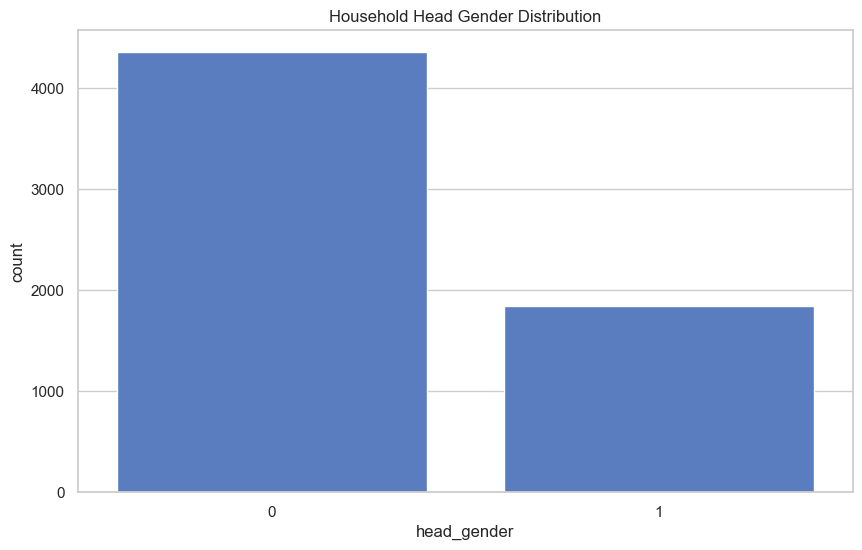

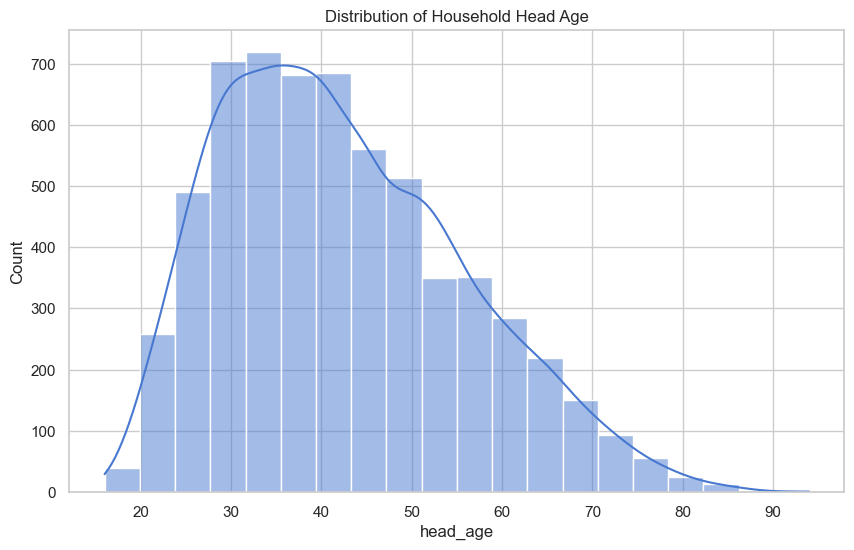

In [117]:
print(final_data[['hh_size','num_dependents','head_age']].describe())

# Gender
sns.countplot(x='head_gender', data=final_data)
plt.title("Household Head Gender Distribution")
plt.show()

# Age 
sns.histplot(final_data['head_age'], bins=20, kde=True)
plt.title("Distribution of Household Head Age")
plt.show()

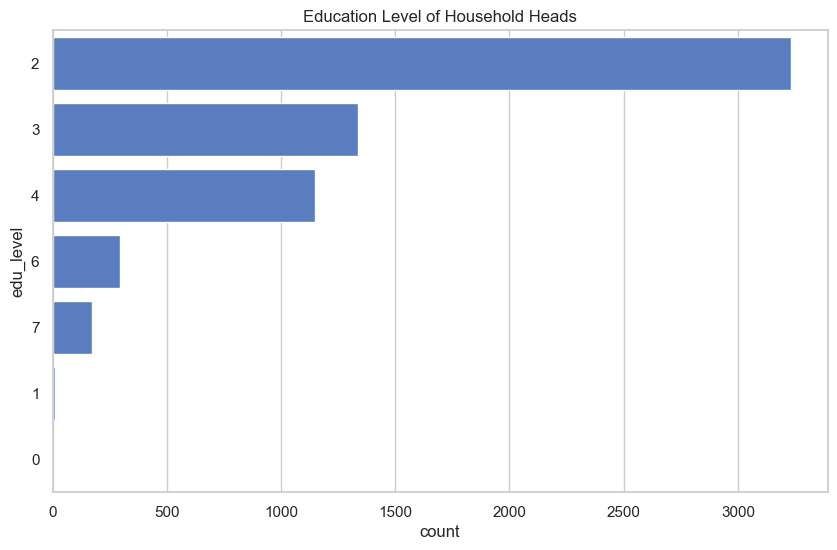

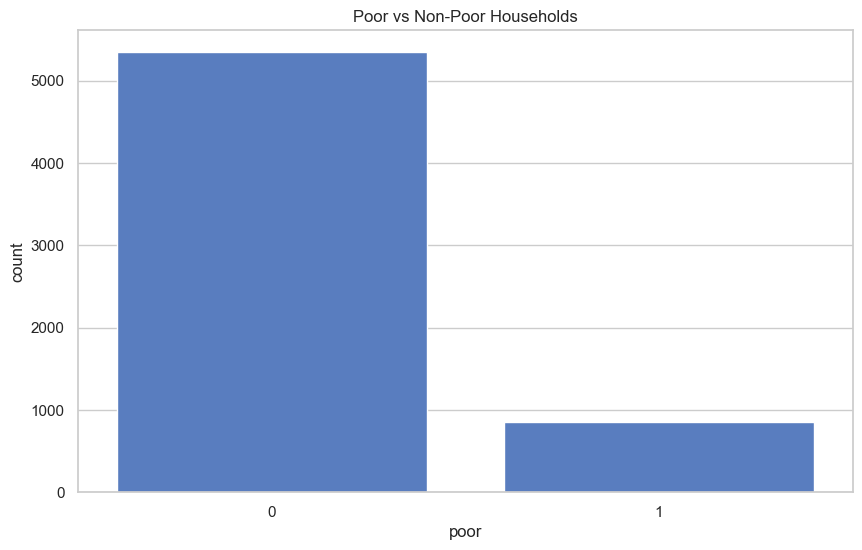

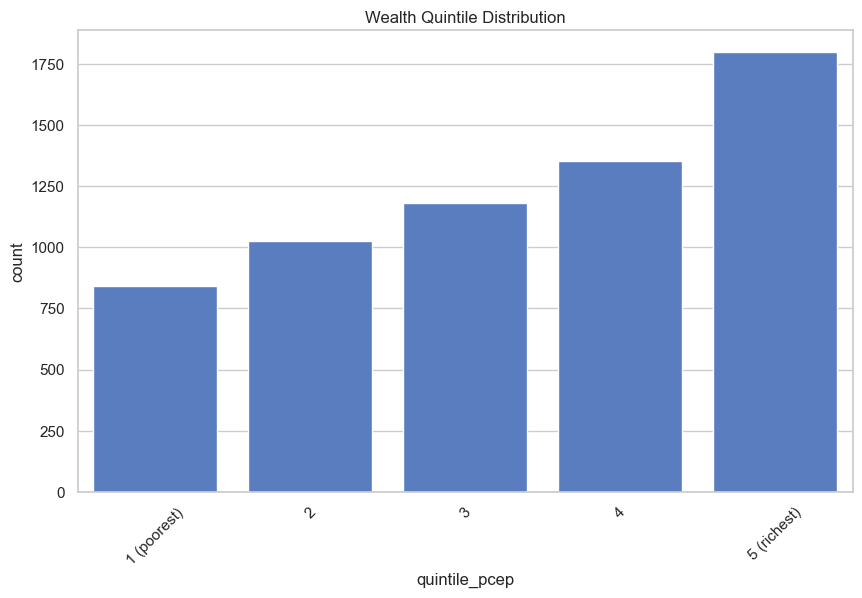

In [118]:
# Education level counts
sns.countplot(y='edu_level', data=final_data, order=final_data['edu_level'].value_counts().index)
plt.title("Education Level of Household Heads")
plt.show()

# poverty 
sns.countplot(x='poor', data=final_data)
plt.title("Poor vs Non-Poor Households")
plt.show()

sns.countplot(x='quintile_pcep', data=final_data)
plt.title("Wealth Quintile Distribution")
plt.xticks(rotation=45)
plt.show()

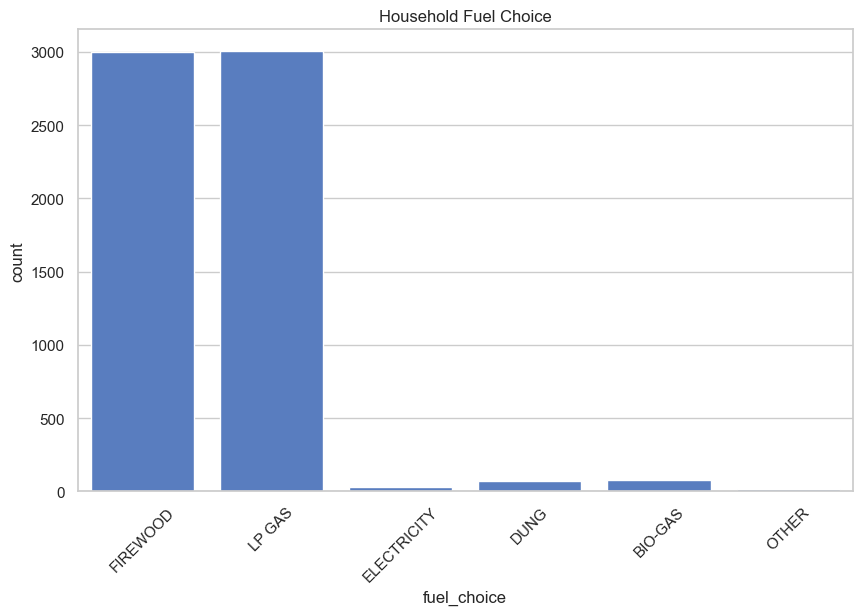

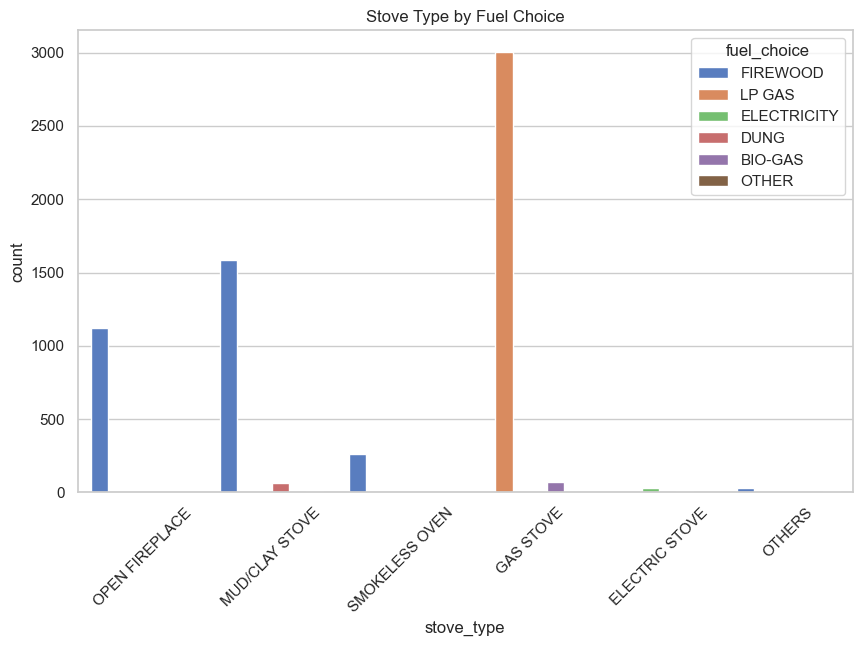

In [119]:
# Fuel choice 
sns.countplot(x='fuel_choice', data=final_data)
plt.title("Household Fuel Choice")
plt.xticks(rotation=45)
plt.show()

# Stove type vs fuel choice
sns.countplot(x='stove_type', hue='fuel_choice', data=final_data)
plt.title("Stove Type by Fuel Choice")
plt.xticks(rotation=45)
plt.show()


In [120]:
# Binary variable for clean fuel
final_data['is_clean_fuel'] = final_data['clean_fuel'].apply(lambda x: 1 if x=='YES' else 0)

# Household dependency ratio
final_data['dependency_ratio'] = final_data['num_dependents'] / final_data['hh_size']

In [121]:
final_data.columns

Index(['hh_id', 'hh_size', 'num_dependents', 'head_gender', 'head_age',
       'fuel_choice', 'stove_type', 'q02_28', 'q02_29', 'q02_30',
       'house_ownership', 'clean_fuel', 'housing', 'idcode', 'edu_lvl',
       'q07_01', 'q07_03', 'psu_number', 'hh_number', 'prov', 'domain', 'poor',
       'quintile_pcep', 'edu_level', 'is_clean_fuel', 'dependency_ratio'],
      dtype='str')

In [122]:
final_data.drop(columns=['q02_28', 'q02_29', 'q02_30', 'q07_03', 'num_dependents', 'dependency_ratio'], inplace=True)

In [123]:
final_data.rename(columns={'q07_01': 'idcode'}, inplace=True)

In [124]:
final_data.head()

,hh_id,hh_size,head_gender,head_age,fuel_choice,stove_type,house_ownership,clean_fuel,housing,idcode,edu_lvl,idcode,psu_number,hh_number,prov,domain,poor,quintile_pcep,edu_level,is_clean_fuel
0,4001_1,2,1,29,LP GAS,GAS STOVE,YES,1,1,1,Class 7,1.0,4001,1,Koshi,Koshi Urban,0,4,3,0
1,4001_10,5,0,44,LP GAS,GAS STOVE,YES,1,1,1,SEE/SLC,2.0,4001,10,Koshi,Koshi Urban,0,4,4,0
2,4001_11,6,0,50,LP GAS,GAS STOVE,YES,1,1,1,Bachelor level,1.0,4001,11,Koshi,Koshi Urban,0,5 (richest),6,0
3,4001_12,8,1,29,FIREWOOD,MUD/CLAY STOVE,NO,0,0,1,SEE/SLC,1.0,4001,12,Koshi,Koshi Urban,0,2,4,0
4,4001_2,2,0,32,FIREWOOD,MUD/CLAY STOVE,NO,0,0,1,Class 5,1.0,4001,2,Koshi,Koshi Urban,0,4,2,0


In [125]:
final_data[['hh_size', 'head_age', 'quintile_pcep']].describe()

,hh_size,head_age
count,6198.000000,6198.000000
mean,3.999839,42.370442
std,1.840721,13.448276
min,1.000000,16.000000
25%,3.000000,32.000000
50%,4.000000,40.000000
75%,5.000000,51.000000
max,21.000000,94.000000


In [126]:
final_data['clean_fuel'].value_counts()

clean_fuel
1    3115
0    3083
Name: count, dtype: int64

In [127]:
final_data['clean_fuel'].value_counts(normalize=True) * 100

clean_fuel
1    50.258148
0    49.741852
Name: proportion, dtype: float64

In [128]:
final_data.groupby('clean_fuel')[['hh_size', 'head_age', 'quintile_pcep']].describe()

hh_size                                               head_age  \
             count      mean       std  min  25%  50%  75%   max    count   
clean_fuel                                                                  
0           3083.0  4.282841  1.891729  1.0  3.0  4.0  5.0  16.0   3083.0   
1           3115.0  3.719743  1.744460  1.0  3.0  4.0  5.0  21.0   3115.0   

                                                                
                 mean        std   min   25%   50%   75%   max  
clean_fuel                                                      
0           42.424911  13.481612  16.0  32.0  40.0  52.0  86.0  
1           42.316533  13.417149  17.0  32.0  40.0  51.0  94.0

In [129]:
from scipy.stats import ttest_ind
clean = final_data[final_data['clean_fuel'] == 1]['hh_size']
non_clean = final_data[final_data['clean_fuel'] == 0]['hh_size']

ttest_ind(clean, non_clean, equal_var=False)

TtestResult(statistic=np.float64(-12.178988369426293), pvalue=np.float64(9.82283890673564e-34), df=np.float64(6144.9322332311485))

In [130]:
clean_gender = final_data[final_data['clean_fuel'] == 1]['head_gender']
non_clean_gender = final_data[final_data['clean_fuel'] == 0]['head_gender']

ttest_ind(clean_gender, non_clean_gender, equal_var=False)

TtestResult(statistic=np.float64(6.343404751795786), pvalue=np.float64(2.4067846214777493e-10), df=np.float64(6172.691114783446))

In [131]:
final_data['quintile_pcep'].dtype
final_data['quintile_pcep'].head(10)

0              4
1              4
2    5 (richest)
3              2
4              4
5              4
6              2
7    1 (poorest)
8    5 (richest)
9              3
Name: quintile_pcep, dtype: category
Categories (5, object): ['1 (poorest)' < 2 < 3 < 4 < '5 (richest)']

In [132]:
final_data['quintile_pcep'] = final_data['quintile_pcep'].astype(str).str.extract('(\d+)')
final_data['quintile_pcep'] = pd.to_numeric(final_data['quintile_pcep'])

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\sapko\AppData\Local\Temp\ipykernel_14728\4275493579.py:1: SyntaxWarning: invalid escape sequence '\d'
  final_data['quintile_pcep'] = final_data['quintile_pcep'].astype(str).str.extract('(\d+)')


In [133]:
corr = ['clean_fuel', 'hh_size', 'head_age', 
                'quintile_pcep', 
                'head_gender']

corr_matrix = final_data[corr].corr()

corr_matrix

,clean_fuel,hh_size,head_age,quintile_pcep,head_gender
clean_fuel,1.000000,-0.152966,-0.004030,0.440817,0.080297
hh_size,-0.152966,1.000000,0.095919,-0.294237,-0.234099
head_age,-0.004030,0.095919,1.000000,0.153045,-0.355377
quintile_pcep,0.440817,-0.294237,0.153045,1.000000,0.041482
head_gender,0.080297,-0.234099,-0.355377,0.041482,1.000000


In [134]:
c = np.corrcoef(corr_matrix.values, rowvar=False)
print(c)

[[ 1.         -0.57636996 -0.24529524  0.62751872  0.07217176]
 [-0.57636996  1.          0.14688224 -0.73390795 -0.50252619]
 [-0.24529524  0.14688224  1.          0.02337851 -0.77202117]
 [ 0.62751872 -0.73390795  0.02337851  1.         -0.00958435]
 [ 0.07217176 -0.50252619 -0.77202117 -0.00958435  1.        ]]


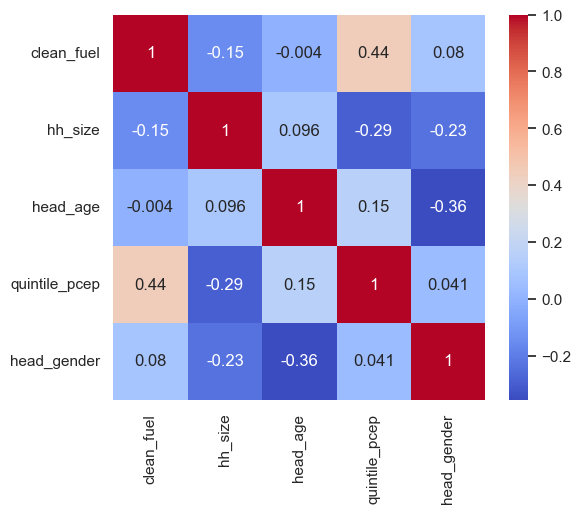

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# plt.scatter(final_data['head_age'], final_data['clean_fuel'])
# plt.xlabel('Head Age')
# plt.ylabel('Clean Fuel (1=Yes, 0=No)')